<a href="https://colab.research.google.com/github/ubsuny/PHY386/blob/Homework2026/2026/HW/zmrozelle/HW2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [78]:
import numpy as np

In [79]:
def build_system(V0, R1, R2, R3, R4, R5):
  r"""
  Returns the coefficient matrix, A, and the right hand side matrix, b, for the bridge ciruit

  The circuit has topology:
     B ----R4----- C--(-)
     |\            |
     | \           |
     R3 \__R5 __   R2
     |          \  |
     |           \ |
(+)--A ----R1----- D

Uses Kirchoff's current and Ohm's law to build linear system Ax=b

Parameters
----------
V0 : float
  Voltage from the source (V)
R1 : float
  Resistance of first resistor (Ohm)
R2 : float
  Resistance of second resistor (Ohm)
R3 : float
  Resistance of third resistor (Ohm)
R4 : float
  Resistance of fourth resistor (Ohm)
R5 : float
  Resistance of fifth resistor (Ohm)

Returns
---------
A : numpy.ndarray
    2x2 coefficient matrix
B : numpy.ndarray
    2x1 right-hand side matrix
"""
  #Coefficient matrix from Kirchoff's and Ohm's laws
  A = np.array([[1/R3 + 1/R4 + 1/R5, -1/R5],
                  [-1/R5, 1/R1 + 1/R2 + 1/R5]], dtype=float)

  #right-hand side vector
  b = np.array([[V0/R3], [V0/R1]], dtype=float)

  #Returns right-hand side vector, b, and coefficient matrix, A
  return A, b

In [80]:
A, b = build_system(10, 100, 200, 300, 600, 50)

print(A)
print(b)

[[ 0.025 -0.02 ]
 [-0.02   0.035]]
[[0.03333333]
 [0.1       ]]


In [83]:
def solve_circuit(A, b, V0, R1, R2, R3, R4, R5):
  """
  Solves the bridge circuit and return all branch currents.

  Uses Kirchoff's and Ohm's laws to set-up system of linear equations AI=b

  Parameters
----------
A : numpy.ndarray
  Coefficient matrix
b : numpy.ndarray
  Right-hand side vector
V0 : float
  Voltage from the source (V)
R1 : float
  Resistance of first resistor  (Ohm)
R2 : float
  Resistance of second resistor  (Ohm)
R3 : float
  Resistance of third resistor  (Ohm)
R4 : float
  Resistance of fourth resistor  (Ohm)
R5 : float
  Resistance of fifth resistor (Ohm)

Returns
---------
currents : numpy.ndarray
    Array [I1, I2, I3, I4, I5] of branch currents
"""

  #Solves linear system for unknown voltages
  unknown_V = np.linalg.solve(A, b)
  VB = unknown_V[0]
  VD= unknown_V[1]

  #Known voltages
  VA = V0
  VC = 0

  #Comput branch currents from Ohm's law
  I1= (VD-VA)/R1
  I2= (VD-VC)/R2
  I3= (VB-VA)/R3
  I4= (VB-VC)/R4
  I5= (VB-VD)/R5

  # Returns current values
  currents= np.array([I1, I2, I3, I4, I5])

  return currents

In [96]:
# Build System
A, b = build_system(10, 100, 200, 300, 600, 50)

# Solve for currents
currents = solve_circuit(A, b, 10, 100, 200, 300, 600, 50)
currents = currents.flatten()

# Print results
print("Branch Currents:")
print(f"I1 = {currents[0]:.4f} A  (through R1)")
print(f"I2 = {currents[1]:.4f} A  (through R2)")
print(f"I3 = {currents[2]:.4f} A  (through R3)")
print(f"I4 = {currents[3]:.4f} A  (through R4)")
print(f"I5 = {currents[4]:.4f} A  (through R5)")

Branch Currents:
I1 = -0.0333 A  (through R1)
I2 = 0.0333 A  (through R2)
I3 = -0.0111 A  (through R3)
I4 = 0.0111 A  (through R4)
I5 = 0.0000 A  (through R5)


In [93]:
def bridge_balance(R1, R2, R3, R4):
  """
  Solves if the bridge circuit is balenced

  Solves the two ration and checks wheter they are equal

  Parameters
  ----------
  R1, R2, R3, R4 : float
    Resistances (Ohm)

  Returns
  ---------
  True or False if bridge is balenced
  """
  ratio1=R1/R3
  ratio2=R2/R4

  if ratio1==ratio2:
    print("Bridge is balenced")
  else:
    print("Bridge is not balenced")

In [95]:
result = bridge_balance(100, 200, 300, 600)

Bridge is balenced


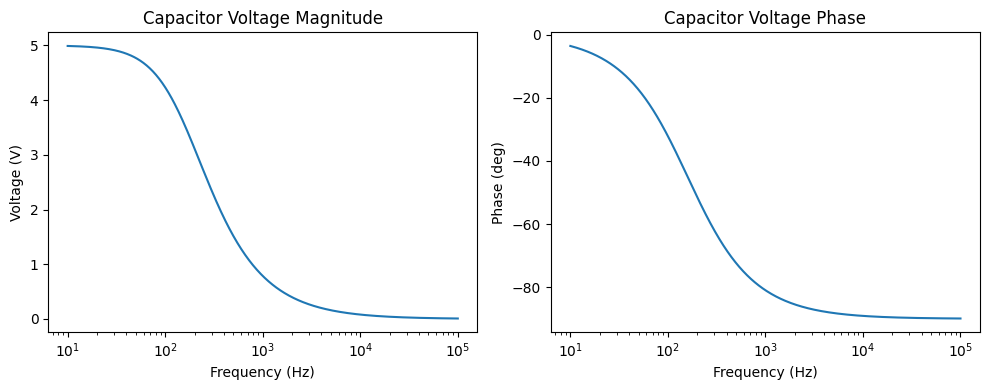

In [97]:
import numpy as np
import matplotlib.pyplot as plt

# Circuit parameters
R = 1000  # ohms
C = 1e-6  # farads
Vs = 5    # volts

# Frequency range
f = np.logspace(1, 5, 500)  # 10 Hz to 100 kHz
omega = 2 * np.pi * f

# Impedances
Z_R = R
Z_C = 1 / (1j * omega * C)

# Voltage across capacitor (complex)
V_C = Vs * Z_C / (Z_R + Z_C)

# Magnitude and phase
V_mag = np.abs(V_C)
V_phase = np.angle(V_C, deg=True)

# Plot
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.semilogx(f, V_mag)
plt.title("Capacitor Voltage Magnitude")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Voltage (V)")

plt.subplot(1,2,2)
plt.semilogx(f, V_phase)
plt.title("Capacitor Voltage Phase")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Phase (deg)")
plt.tight_layout()
plt.show()

I gave the prompt to Chat GPT. It handeled the prompt very well, adding a capacitor to the circuit to create a low-pass filter. It produced a physically reasonable code on the first try. Low-pass filters are often added to circuits to allow easy passage for low-frequency signals and difficult passage for high-frequency signals. Therefore, the graph produced is correct as the voltage decreases as frequency increases. We see low pass filters often used in radar systems where they are needed to remove high-frequency background noise in order to pick a clear low-frequency signal.